In [1]:
import pandas as pd
import os
import scanpy as sc
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import shutil
import muon as mu
import scirpy as ir
import anndata
from tqdm import tqdm
from scipy.stats import entropy
import matplotlib.patches as mpatches

import rpy2
import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri

from rpy2.robjects.conversion import localconverter

%load_ext rpy2.ipython

/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/jupyter/mambaforge/envs/python38/lib/python3.8/site-packag

In [2]:
adata = sc.read_h5ad('/home/jupyter/data/ge_korea/results/tcr_analysis/mvtcr_adata_new_correct_progression.h5ad')
adata.obs['progression'] = adata.obs['patient'].map({
 'E30': 'Fast',
 'E26': 'Slow',
 'E15': 'Slow',
 'E21': 'Slow',
 'E43': 'Fast',
 'E37': 'Slow',
 'E14': 'Fast',
 'E44': 'Fast',
 'E36': 'Slow',
 'E42': 'Slow',
 'E31': 'Fast',
 'E17': 'Slow',
 'E38': 'Slow',
 'E16': 'Fast',
 'E24': 'Slow',
 'E22': 'Fast',
 'E45': 'Fast',
 'E35': 'Slow',
 'E33': 'Slow',
 'E27': 'Fast',
 'E23': 'Slow',
 'E34': 'Fast',
 'E39': 'Slow',
 'E25': 'Fast',
 'E41': 'Slow',
 'E12': 'Fast',
 'E18': 'Slow',
 'E20': 'Slow',
 'E32': 'Fast',
 'E46': 'Fast',
 'E40': 'Slow',
 'E29': 'Slow',
 'E19': 'Fast'})

In [3]:
adata.obs[['patient','progression']].drop_duplicates()['progression'].value_counts()

Slow    18
Fast    15
Name: progression, dtype: int64

In [4]:
adata_t = sc.read_h5ad('/home/jupyter/data/ge_korea/results/ge_korea_tnk_annotation_new.h5ad')


In [5]:
adata = adata[adata.obs['annot_final'].isin([
     'CD8 Tem Cell',
     'Tactiv Cell',
     'GZMK+ CD8 T progenitor ex Cell',
     'Th17/Tc17',
     'Tc17',
     'CD8 Cytotoxic T Cell',
     'CD8 HSP T cell',
     'Tprolif Cell',
     'T naive/early memory Cell',
     'Terminal CD8 Tex Cell',
])]

In [6]:
adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)

/tmp/ipykernel_1566/3600024150.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['clonotype_patient'] = adata.obs['clonotype'].astype(str) + '_' + adata.obs['patient'].astype(str)


In [7]:
color_dict = {
    'T naive/early memory Cell' : '#1f77b4',
    'GZMK+ CD8 T progenitor ex Cell' : '#aec7e8',
    'CD8 Tem Cell' : '#ff7f0e',
    'Tactiv Cell' : '#ffbb78',
    'CD8 HSP T cell' : '#98df8a',
    'CD8 T naive/early memory Cell' : '#d62728',
    'CD4 T naive/early memory Cell' : '#ff9896',
    'CD8 Cytotoxic T Cell' : '#9467bd',
    'Tprolif Cell' : '#8c564b',
    'Treg' : '#c49c94',
    'Tc17' : '#e377c2',
    'Terminal CD8 Tex Cell' : '#f7b6d2',
    'Th17/Tc17' : '#c7c7c7',
    'gd T Cell' : '#bcbd22',
    'NKT' : '#dbdb8d',
    'Th17' : '#17becf',
    'Tnaive Cell' : '#9edae5'
}

In [8]:
patient_progression = adata.obs[['patient','progression']].drop_duplicates()
patient_progression.index = patient_progression['patient']
patient_progression = patient_progression['progression'].to_dict()

# B - F1

In [9]:
adata_bf1 = adata[adata.obs['timepoint'].isin(['B','F1'])]

In [10]:
clonotype_counts_b = adata_bf1[adata_bf1.obs['timepoint'] == 'B'].obs['clonotype_patient'].value_counts()
clonotype_counts_f1 = adata_bf1[adata_bf1.obs['timepoint'] == 'F1'].obs['clonotype_patient'].value_counts()

In [11]:
clonotype_counts_b

11840_E25    83
10475_E15    76
9895_E30     70
3931_E31     60
18991_E20    59
             ..
17231_E18     1
17233_E18     1
17235_E18     1
17239_E18     1
9101_E23      1
Name: clonotype_patient, Length: 11248, dtype: int64

In [12]:
clonotype_counts_bf1 = pd.concat([clonotype_counts_b,
                                  clonotype_counts_f1],axis=1)
clonotype_counts_bf1 = clonotype_counts_bf1.dropna()
clonotype_counts_bf1.columns = ['B','F1']

In [13]:
sample_counts = pd.read_csv('/home/jupyter/data/ge_korea/results/tcr_analysis/cell_counts_by_sample.csv')

In [14]:
sample_counts.index = sample_counts['Sample']
sample_counts

,Sample,Timepoint_Progression,Total,Immune,T cells
Sample,,,,,
E12_B,E12_B,B_Slow,833,644,358
E12_F1,E12_F1,F1_Slow,4651,3929,2906
E12_F2,E12_F2,F2_Slow,4240,3355,2253
E14_B,E14_B,B_Fast,1003,609,322
E14_F1,E14_F1,F1_Fast,1073,521,310
...,...,...,...,...,...
E45_F1,E45_F1,F1_Slow,2391,2032,737
E45_F2,E45_F2,F2_Slow,578,536,83
E46_B,E46_B,B_Slow,1993,436,175


In [15]:
b_props = []
f1_props = []
for i in clonotype_counts_bf1.index:
    temp = i.split('_')[1]
    b_count = sample_counts.loc[temp + '_B','T cells']
    f1_count = sample_counts.loc[temp + '_F1','T cells']
    b_props.append(clonotype_counts_bf1.loc[i,'B'] / b_count)
    f1_props.append(clonotype_counts_bf1.loc[i,'F1'] / f1_count)

In [16]:
clonotype_counts_bf1_norm = pd.DataFrame({'B' : b_props,
                                          'F1' : f1_props},index=clonotype_counts_bf1.index)

In [17]:
expanding_clones = [i for i in clonotype_counts_bf1_norm.index if (clonotype_counts_bf1_norm.loc[i,'F1'] - .001) >= clonotype_counts_bf1_norm.loc[i,'B']]
contracting_clones = [i for i in clonotype_counts_bf1_norm.index if (clonotype_counts_bf1_norm.loc[i,'B'] - .001) >= clonotype_counts_bf1_norm.loc[i,'F1']]

In [18]:
expanding_clones_bf1 = expanding_clones
contracting_clones_bf1 = contracting_clones
nonexpanding_clones_bf1 = [i for i in clonotype_counts_bf1_norm.index if i not in expanding_clones]
shared_clones_bf1 = clonotype_counts_bf1_norm.index.tolist()

In [19]:
dist_b = adata[(adata.obs['clonotype_patient'].isin(
    expanding_clones)) & (
    adata.obs['timepoint'] == 'B'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0).mean(axis=0)
dist_f1 = adata[(adata.obs['clonotype_patient'].isin(
    expanding_clones)) & (
    adata.obs['timepoint'] == 'F1'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0).mean(axis=0)

# F1 - F2

In [20]:
adata_f1f2 = adata[adata.obs['timepoint'].isin(['F1','F2'])]

In [21]:
clonotype_counts_f1 = adata_f1f2[adata_f1f2.obs['timepoint'] == 'F1'].obs['clonotype_patient'].value_counts()
clonotype_counts_f2 = adata_f1f2[adata_f1f2.obs['timepoint'] == 'F2'].obs['clonotype_patient'].value_counts()

In [22]:
clonotype_counts_f1f2 = pd.concat([clonotype_counts_f1,
                                  clonotype_counts_f2],axis=1)
clonotype_counts_f1f2 = clonotype_counts_f1f2.dropna()
clonotype_counts_f1f2.columns = ['F1','F2']

In [23]:
f1_props = []
f2_props = []
for i in clonotype_counts_f1f2.index:
    temp = i.split('_')[1]
    f1_count = sample_counts.loc[temp + '_F1','T cells']
    f2_count = sample_counts.loc[temp + '_F2','T cells']
    f1_props.append(clonotype_counts_f1f2.loc[i,'F1'] / f1_count)
    f2_props.append(clonotype_counts_f1f2.loc[i,'F2'] / f2_count)

In [24]:
clonotype_counts_f1f2_norm = pd.DataFrame({'F1' : f1_props,
                                           'F2' : f2_props},index=clonotype_counts_f1f2.index)

In [25]:
expanding_clones = [i for i in clonotype_counts_f1f2_norm.index if (clonotype_counts_f1f2_norm.loc[i,'F2'] - 0.001) >= clonotype_counts_f1f2_norm.loc[i,'F1']]
contracting_clones = [i for i in clonotype_counts_f1f2_norm.index if (clonotype_counts_f1f2_norm.loc[i,'F1'] - 0.001) >= clonotype_counts_f1f2_norm.loc[i,'F2']]

In [26]:
expanding_clones_f1f2 = expanding_clones
contracting_clones_f1f2 = contracting_clones
nonexpanding_clones_f1f2 = [i for i in clonotype_counts_f1f2_norm.index if i not in expanding_clones]
shared_clones_f1f2 = clonotype_counts_f1f2_norm.index.tolist()

In [27]:
status = []
patient = []
progression = []
clonotype_counts_f1f2_norm_progression = clonotype_counts_f1f2_norm.copy()
del clonotype_counts_f1f2_norm_progression['F1']
del clonotype_counts_f1f2_norm_progression['F2']
for i in clonotype_counts_f1f2_norm_progression.index:
    if i in expanding_clones_f1f2:
        status.append('expanded')
    elif i in contracting_clones_f1f2:
        status.append('contract')
    else:
        status.append('stable')
    patient.append(i.split('_')[1])
    progression.append(patient_progression[i.split('_')[1]])

In [28]:
clonotype_counts_f1f2_norm_progression['status'] = status
clonotype_counts_f1f2_norm_progression['patient'] = patient
clonotype_counts_f1f2_norm_progression['progression'] = progression

# Shared clones above threshold

In [29]:
spectra_tr_score = pd.read_csv(
    '/home/jupyter/data/ge_korea/results/tcr_analysis/spectra_tr/tcells_UCell_TRsig_scored.csv')
del spectra_tr_score['Unnamed: 0']
spectra_tr_score.index = spectra_tr_score['V2']
del spectra_tr_score['V2']
spectra_tr_score.columns = ['TR_Score']

In [30]:
adata.obs['spectra_tr_score'] = spectra_tr_score['TR_Score']

In [31]:
adata.obs['spectra_tr_score_binary'] = (
    adata.obs['spectra_tr_score'] > 0.285).map({True : 'TR',
                                             False : 'Not TR'})

In [32]:
tr_clonotype_patient = adata[
    adata.obs['spectra_tr_score_binary'] == 'TR'].obs['clonotype_patient'].unique().tolist()
tr_barcodes = pd.DataFrame(adata[adata.obs['clonotype_patient'].isin(tr_clonotype_patient)].obs_names)
tr_barcodes['identity'] = ['TR'] * len(tr_barcodes)
tr_barcodes.index = tr_barcodes['sample_index']
adata.obs['TR_cell'] = tr_barcodes['identity']

In [33]:
adata_non_tr = adata[adata.obs['TR_cell'].isnull()].copy()

In [34]:
adata_non_tr.obs['progression_timepoint'] = adata_non_tr.obs['progression'].astype(str) + ' ' + adata_non_tr.obs['timepoint'].astype(str)
progression_timepoint_dict = adata_non_tr.obs[['progression_timepoint','sample_x']].drop_duplicates()
progression_timepoint_dict.index = progression_timepoint_dict['sample_x']
progression_timepoint_dict = progression_timepoint_dict['progression_timepoint'].to_dict()

Text(0.5, 1.0, 'Phenotypic distribution of non-putative TR clones')

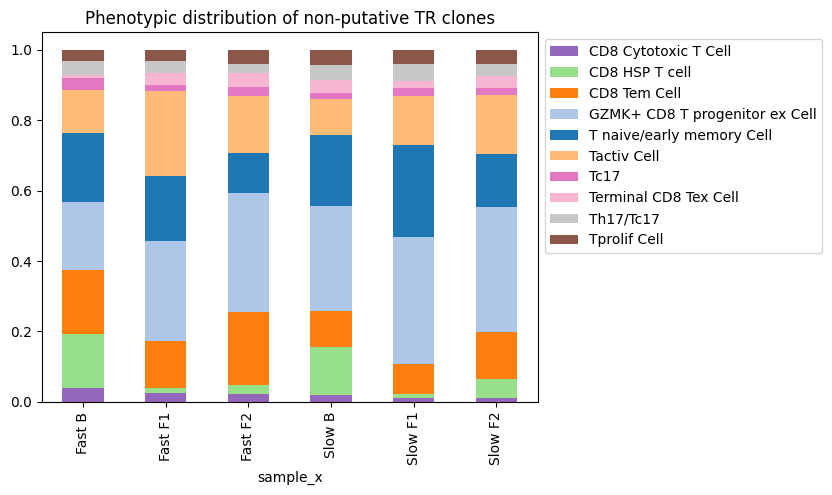

In [35]:
temp=adata_non_tr.obs[['sample_x','annot_final']].value_counts().reset_index().pivot(
    index='sample_x',columns='annot_final',values=0
).fillna(0)
temp = temp.div(temp.sum(axis=1),axis=0)
temp.index = temp.index.map(progression_timepoint_dict)
temp.groupby(temp.index).mean().plot(kind='bar',stacked=True,color=color_dict)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Phenotypic distribution of non-putative TR clones')

Text(0.5, 1.0, 'Phenotypic distribution of putative TR clones')

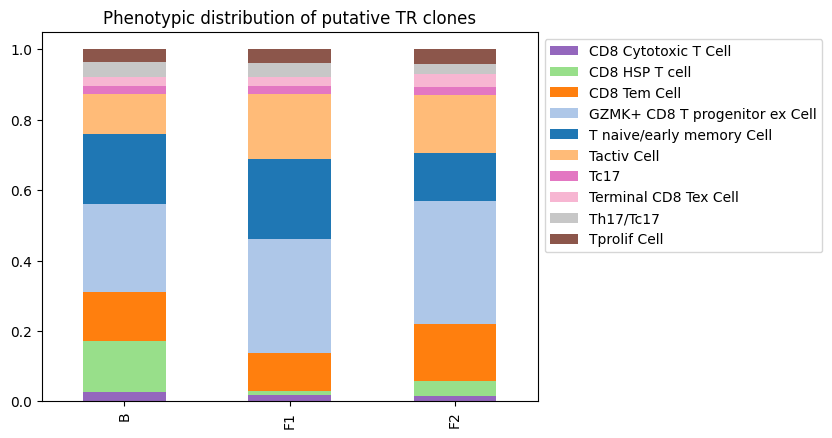

In [36]:
temp.index = [i.split(' ')[1] for i in temp.index]
temp.groupby(temp.index).mean().plot(kind='bar',stacked=True,color=color_dict)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Phenotypic distribution of putative TR clones')

In [37]:
adata = adata[~adata.obs['TR_cell'].isnull()].copy()

In [38]:
adata.obs['progression_timepoint'] = adata.obs['progression'].astype(str) + ' ' + adata.obs['timepoint'].astype(str)
progression_timepoint_dict = adata.obs[['progression_timepoint','sample_x']].drop_duplicates()
progression_timepoint_dict.index = progression_timepoint_dict['sample_x']
progression_timepoint_dict = progression_timepoint_dict['progression_timepoint'].to_dict()

Text(0.5, 1.0, 'Phenotypic distribution of putative TR clones')

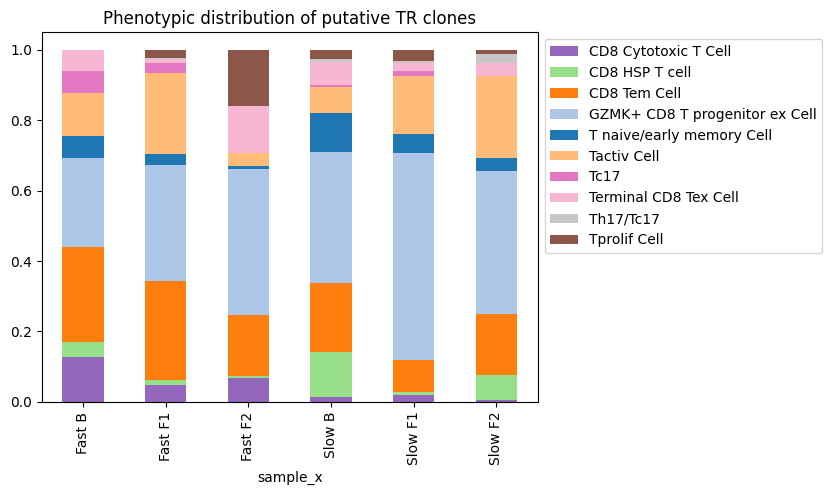

In [39]:
temp=adata.obs[['sample_x','annot_final']].value_counts().reset_index().pivot(
    index='sample_x',columns='annot_final',values=0
).fillna(0)
temp = temp.div(temp.sum(axis=1),axis=0)
temp.index = temp.index.map(progression_timepoint_dict)
temp.groupby(temp.index).mean().plot(kind='bar',stacked=True,color=color_dict)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Phenotypic distribution of putative TR clones')

Text(0.5, 1.0, 'Phenotypic distribution of putative TR clones shared across all time points')

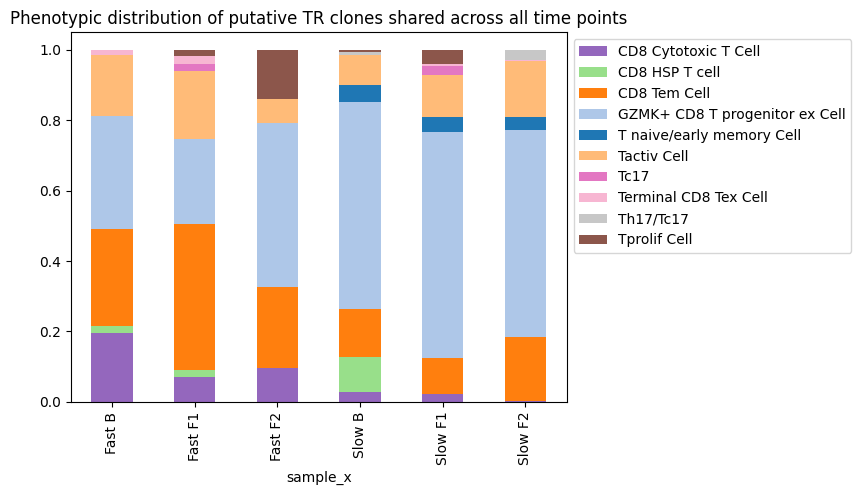

In [40]:
temp=adata[adata.obs['clonotype_patient'].isin(
    shared_clones_bf1 + shared_clones_f1f2)].obs[['sample_x','annot_final']].value_counts().reset_index().pivot(
    index='sample_x',columns='annot_final',values=0
).fillna(0)
temp = temp.div(temp.sum(axis=1),axis=0)
temp.index = temp.index.map(progression_timepoint_dict)
temp.groupby(temp.index).mean().plot(kind='bar',stacked=True,color=color_dict)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Phenotypic distribution of putative TR clones shared across all time points')

Text(0.5, 1.0, 'Phenotypic distribution of putative TR clones')

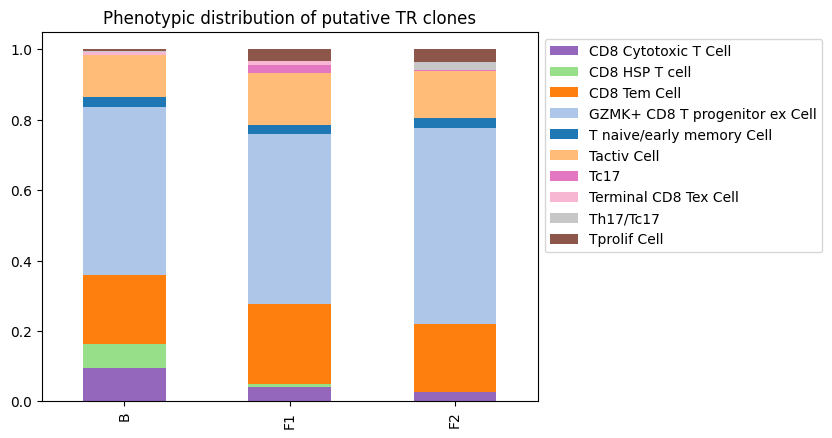

In [41]:
temp.index = [i.split(' ')[1] for i in temp.index]
temp.groupby(temp.index).mean().plot(kind='bar',stacked=True,color=color_dict)
plt.legend(bbox_to_anchor=(1,1))
plt.title('Phenotypic distribution of putative TR clones')

In [42]:
adata.obs['TR_cell'].index

Index(['E26_F2_GGACATTAGCCGATTT', 'E26_F2_TACGGTACACGCCAGT',
       'E26_F2_TTCTCCTTCGTCTGAA', 'E15_F1_AAGGCAGTCTTGTATC',
       'E15_F1_ACATCAGGTCATACTG', 'E15_F1_ACATCAGTCATGCAAC',
       'E15_F1_ACCCACTCACAACGTT', 'E15_F1_ACTGAGTAGGAGTACC',
       'E15_F1_AGGTCCGGTATAGTAG', 'E15_F1_ATTCTACCAAGTAATG',
       ...
       'E29_F1_TAGAGCTCAGGACGTA', 'E29_F1_TAGGCATTCATTATCC',
       'E29_F1_TATCTCACAGCTGTTA', 'E29_F1_TCCACACAGCTAGCCC',
       'E29_F1_TGCCAAACAAAGGCGT', 'E29_F1_TGCTGCTCAGCGATCC',
       'E29_F1_TTAGTTCGTTAAGACA', 'E29_F1_TTCTACAGTGGCGAAT',
       'E29_F1_TTCTCAAGTCTAGCCG', 'E29_F1_TTGCCGTTCCTTGACC'],
      dtype='object', name='sample_index', length=3552)

# Alluvial Plots (all)

In [43]:
dist_b_slow = adata[(
    adata.obs['timepoint'] == 'B'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_b_slow = dist_b_slow.div(dist_b_slow.sum(axis=1),axis=0)

dist_f1_slow =  adata[(
    adata.obs['timepoint'] == 'F1'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f1_slow = dist_f1_slow.div(dist_f1_slow.sum(axis=1),axis=0)

dist_f2_slow = adata[(
    adata.obs['timepoint'] == 'F2'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f2_slow = dist_f2_slow.div(dist_f2_slow.sum(axis=1),axis=0)

In [44]:
import random
clonotype_end = {}
for i in dist_f2_slow.index:
    temp = dist_f2_slow.loc[i]
    if temp.max() == 0.5:
        clonotype_end[i] = random.choice(temp[temp == .5].index.tolist())
    else:
        clonotype_end[i] = temp.idxmax()

In [45]:
dist_f1_slow.index = dist_f1_slow.index.map(clonotype_end)

In [46]:
dist_f1_slow_grouped = dist_f1_slow.groupby(level=0).sum()

In [47]:
dist_f1_slow_grouped.index = [i + ' ' for i in dist_f1_slow_grouped.index]

In [48]:
import sys
sys.path.append(os.path.abspath("/home/jupyter/data/ge_korea/notebooks_2024/tcr_analysis"))
import alluvial

In [49]:
flow_dict = dist_f1_slow_grouped.to_dict()

In [50]:
flow_dict_sub = {i : v for i , v in flow_dict.items()}

In [51]:
flow_dict_sub_new = {}
for i in flow_dict_sub.keys():
    temp = flow_dict_sub[i]
    flow_dict_sub_new[i] = {i : v for i, v in temp.items() if v > 0}

In [52]:
flow_dict_sub_new.keys()

dict_keys(['CD8 Cytotoxic T Cell', 'CD8 HSP T cell', 'CD8 Tem Cell', 'GZMK+ CD8 T progenitor ex Cell', 'T naive/early memory Cell', 'Tactiv Cell', 'Tc17', 'Terminal CD8 Tex Cell', 'Th17/Tc17', 'Tprolif Cell'])

In [53]:
colors = ['Terminal CD8 Tex Cell','CD8 HSP T cell',
          'Th17/Tc17','Tprolif Cell','CD8 Cytotoxic T Cell',
          'Tc17','T naive/early memory Cell',
          'CD8 Tem Cell',
          'Tactiv Cell',
          'GZMK+ CD8 T progenitor ex Cell']
colors = [color_dict[i] for i in colors]

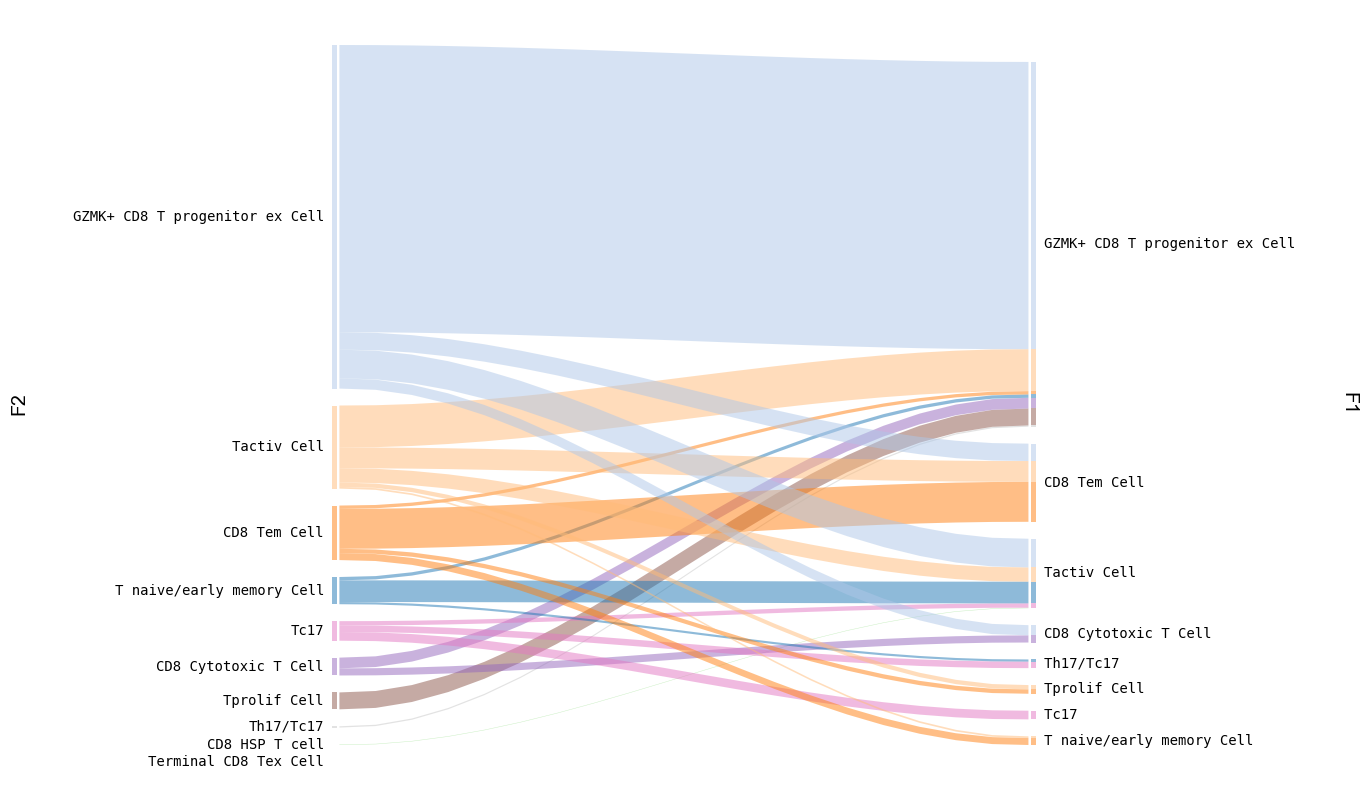

In [54]:
ax=alluvial.plot(flow_dict_sub_new,
                 colors=colors,
                 color_side=0,labels=('F2','F1'),h_gap_frac=0.015)
fig = ax.get_figure()
fig.set_size_inches(10,10)
#ax.set_title('Origins of Shared Clones at in Slow Progressors F2', fontsize=14, fontname='Monospace')
plt.show()

In [55]:
dist_b_slow = adata[(
    adata.obs['timepoint'] == 'B'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_b_slow = dist_b_slow.div(dist_b_slow.sum(axis=1),axis=0)

dist_f1_slow =  adata[(
    adata.obs['timepoint'] == 'F1'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f1_slow = dist_f1_slow.div(dist_f1_slow.sum(axis=1),axis=0)

dist_f2_slow = adata[(
    adata.obs['timepoint'] == 'F2'
    )].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f2_slow = dist_f2_slow.div(dist_f2_slow.sum(axis=1),axis=0)

In [56]:
import random
clonotype_end = {}
for i in dist_f1_slow.index:
    temp = dist_f1_slow.loc[i]
    if temp.max() == 0.5:
        clonotype_end[i] = random.choice(temp[temp == .5].index.tolist())
    else:
        clonotype_end[i] = temp.idxmax()

In [57]:
dist_b_slow.index = dist_b_slow.index.map(clonotype_end)

In [58]:
dist_b_slow_grouped = dist_b_slow.groupby(level=0).sum()

In [59]:
dist_b_slow_grouped.index = [i + ' ' for i in dist_b_slow_grouped.index]

In [60]:
flow_dict = dist_b_slow_grouped.to_dict()

In [61]:
flow_dict_sub = {i : v for i , v in flow_dict.items()}

In [62]:
flow_dict_sub_new = {}
for i in flow_dict_sub.keys():
    temp = flow_dict_sub[i]
    flow_dict_sub_new[i] = {i : v for i, v in temp.items() if v > 0}

In [63]:
colors=['Terminal CD8 Tex Cell','Th17/Tc17','Tc17',
        'Tprolif Cell','T naive/early memory Cell','CD8 Cytotoxic T Cell','CD8 HSP T cell',
        'Tactiv Cell','CD8 Tem Cell',
        'GZMK+ CD8 T progenitor ex Cell']
colors = [color_dict[i] for i in colors]

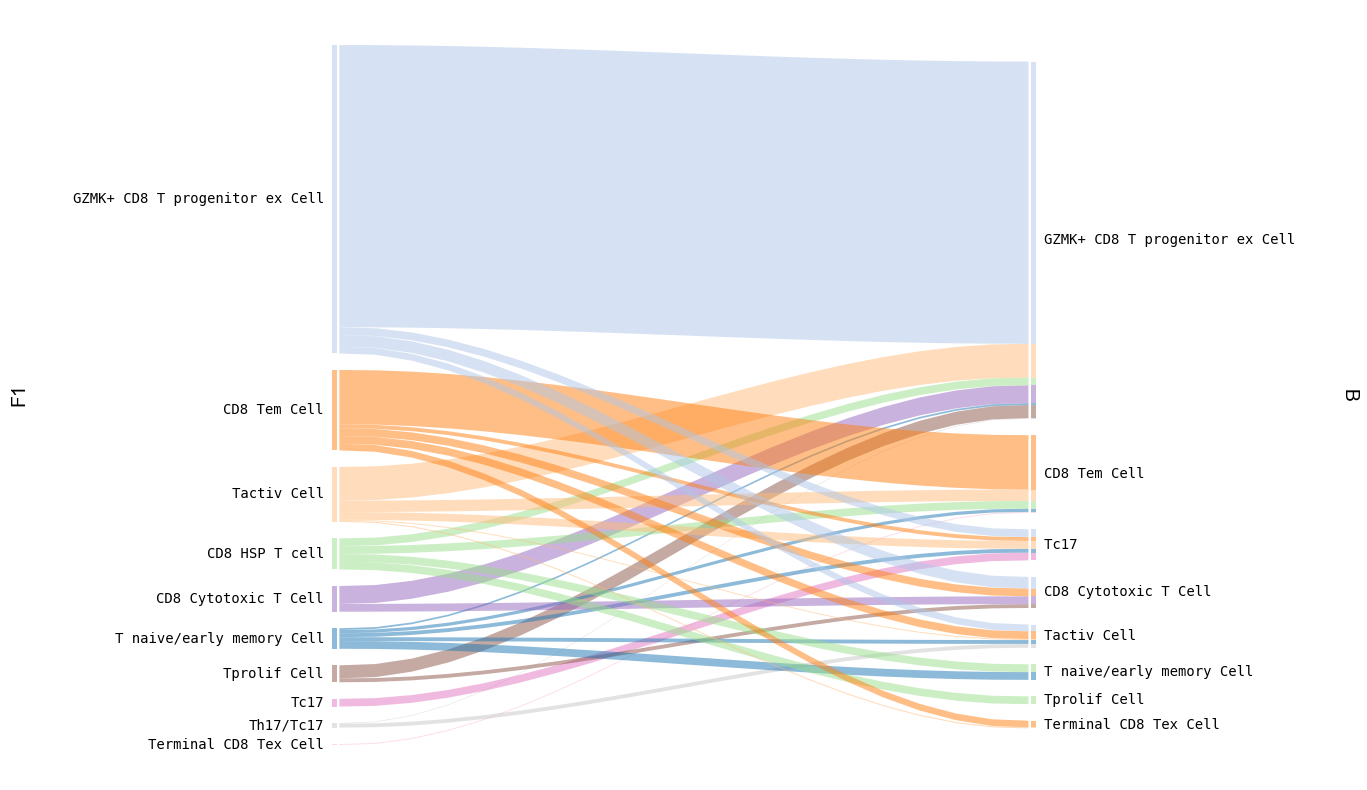

In [64]:
ax=alluvial.plot(flow_dict_sub,
                 colors=colors,
                 color_side=0,labels=('F1','B'),h_gap_frac=0.015)
fig = ax.get_figure()
fig.set_size_inches(10,10)
#ax.set_title('Origins of Shared Clones at in Fast Progressors F1', fontsize=14, fontname='Monospace')
plt.show()

# Alluvial Plots (slow)

In [65]:
dist_b_slow = adata[(
    adata.obs['timepoint'] == 'B'
    ) & (adata.obs['progression'] == 'Slow')].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_b_slow = dist_b_slow.div(dist_b_slow.sum(axis=1),axis=0)

dist_f1_slow =  adata[(
    adata.obs['timepoint'] == 'F1'
    ) & (adata.obs['progression'] == 'Slow')].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f1_slow = dist_f1_slow.div(dist_f1_slow.sum(axis=1),axis=0)

dist_f2_slow = adata[(
    adata.obs['timepoint'] == 'F2'
    ) & (adata.obs['progression'] == 'Slow')].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f2_slow = dist_f2_slow.div(dist_f2_slow.sum(axis=1),axis=0)

In [66]:
import random
clonotype_end = {}
for i in dist_f2_slow.index:
    temp = dist_f2_slow.loc[i]
    if temp.max() == 0.5:
        clonotype_end[i] = random.choice(temp[temp == .5].index.tolist())
    else:
        clonotype_end[i] = temp.idxmax()

In [67]:
dist_f1_slow.index = dist_f1_slow.index.map(clonotype_end)

In [68]:
dist_f1_slow_grouped = dist_f1_slow.groupby(level=0).sum()

In [69]:
dist_f1_slow_grouped.index = [i + ' ' for i in dist_f1_slow_grouped.index]

In [70]:
import sys
sys.path.append(os.path.abspath("/home/jupyter/data/ge_korea/tcr_analysis/notebooks_2024"))
import alluvial

In [71]:
flow_dict = dist_f1_slow_grouped.to_dict()

In [72]:
flow_dict_sub = {i : v for i , v in flow_dict.items()}

In [73]:
flow_dict_sub_new = {}
for i in flow_dict_sub.keys():
    temp = flow_dict_sub[i]
    flow_dict_sub_new[i] = {i : v for i, v in temp.items() if v > 0}

In [74]:
flow_dict_sub_new.keys()

dict_keys(['CD8 Cytotoxic T Cell', 'CD8 HSP T cell', 'CD8 Tem Cell', 'GZMK+ CD8 T progenitor ex Cell', 'T naive/early memory Cell', 'Tactiv Cell', 'Tc17', 'Terminal CD8 Tex Cell', 'Th17/Tc17', 'Tprolif Cell'])

In [75]:
colors

['#f7b6d2',
 '#c7c7c7',
 '#e377c2',
 '#8c564b',
 '#1f77b4',
 '#9467bd',
 '#98df8a',
 '#ffbb78',
 '#ff7f0e',
 '#aec7e8']

In [76]:
colors = ['Terminal CD8 Tex Cell','CD8 HSP T cell',
          'Th17/Tc17','Tprolif Cell','CD8 Cytotoxic T Cell',
          'Tc17','T naive/early memory Cell',
          'CD8 Tem Cell',
          'Tactiv Cell',
          'GZMK+ CD8 T progenitor ex Cell']
colors = [color_dict[i] for i in colors]

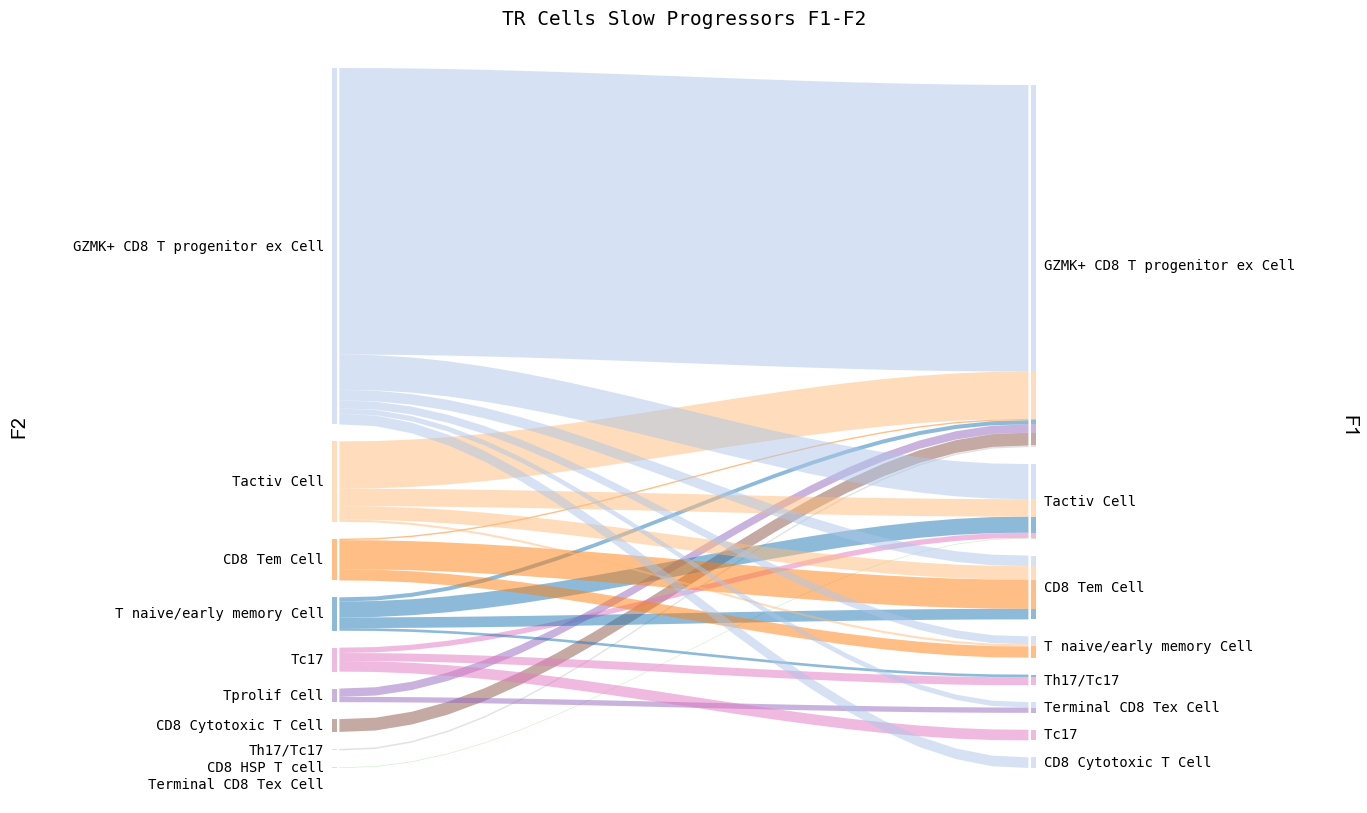

In [77]:
ax=alluvial.plot(flow_dict_sub_new,
                 colors=colors,
                 color_side=0,labels=('F2','F1'),h_gap_frac=0.015)
fig = ax.get_figure()
fig.set_size_inches(10,10)
ax.set_title('TR Cells Slow Progressors F1-F2', fontsize=14, fontname='Monospace')
plt.show()

In [78]:
dist_b_slow = adata[(
    adata.obs['timepoint'] == 'B'
    ) & (adata.obs['progression'] == 'Slow')].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_b_slow = dist_b_slow.div(dist_b_slow.sum(axis=1),axis=0)

dist_f1_slow =  adata[(
    adata.obs['timepoint'] == 'F1'
    ) & (adata.obs['progression'] == 'Slow')].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f1_slow = dist_f1_slow.div(dist_f1_slow.sum(axis=1),axis=0)

dist_f2_slow = adata[(
    adata.obs['timepoint'] == 'F2'
    ) & (adata.obs['progression'] == 'Slow')].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f2_slow = dist_f2_slow.div(dist_f2_slow.sum(axis=1),axis=0)

In [79]:
import random
clonotype_end = {}
for i in dist_f1_slow.index:
    temp = dist_f1_slow.loc[i]
    if temp.max() == 0.5:
        clonotype_end[i] = random.choice(temp[temp == .5].index.tolist())
    else:
        clonotype_end[i] = temp.idxmax()

In [80]:
dist_b_slow.index = dist_b_slow.index.map(clonotype_end)

In [81]:
dist_b_slow_grouped = dist_b_slow.groupby(level=0).sum()

In [82]:
dist_b_slow_grouped.index = [i + ' ' for i in dist_b_slow_grouped.index]

In [83]:
flow_dict = dist_b_slow_grouped.to_dict()

In [84]:
flow_dict_sub = {i : v for i , v in flow_dict.items()}

In [85]:
flow_dict_sub_new = {}
for i in flow_dict_sub.keys():
    temp = flow_dict_sub[i]
    flow_dict_sub_new[i] = {i : v for i, v in temp.items() if v > 0}

In [86]:
colors=['Terminal CD8 Tex Cell','Th17/Tc17','Tc17',
        'Tprolif Cell','T naive/early memory Cell',
        'CD8 Cytotoxic T Cell','CD8 HSP T cell',
        'Tactiv Cell','CD8 Tem Cell',
        'GZMK+ CD8 T progenitor ex Cell']
colors = [color_dict[i] for i in colors]

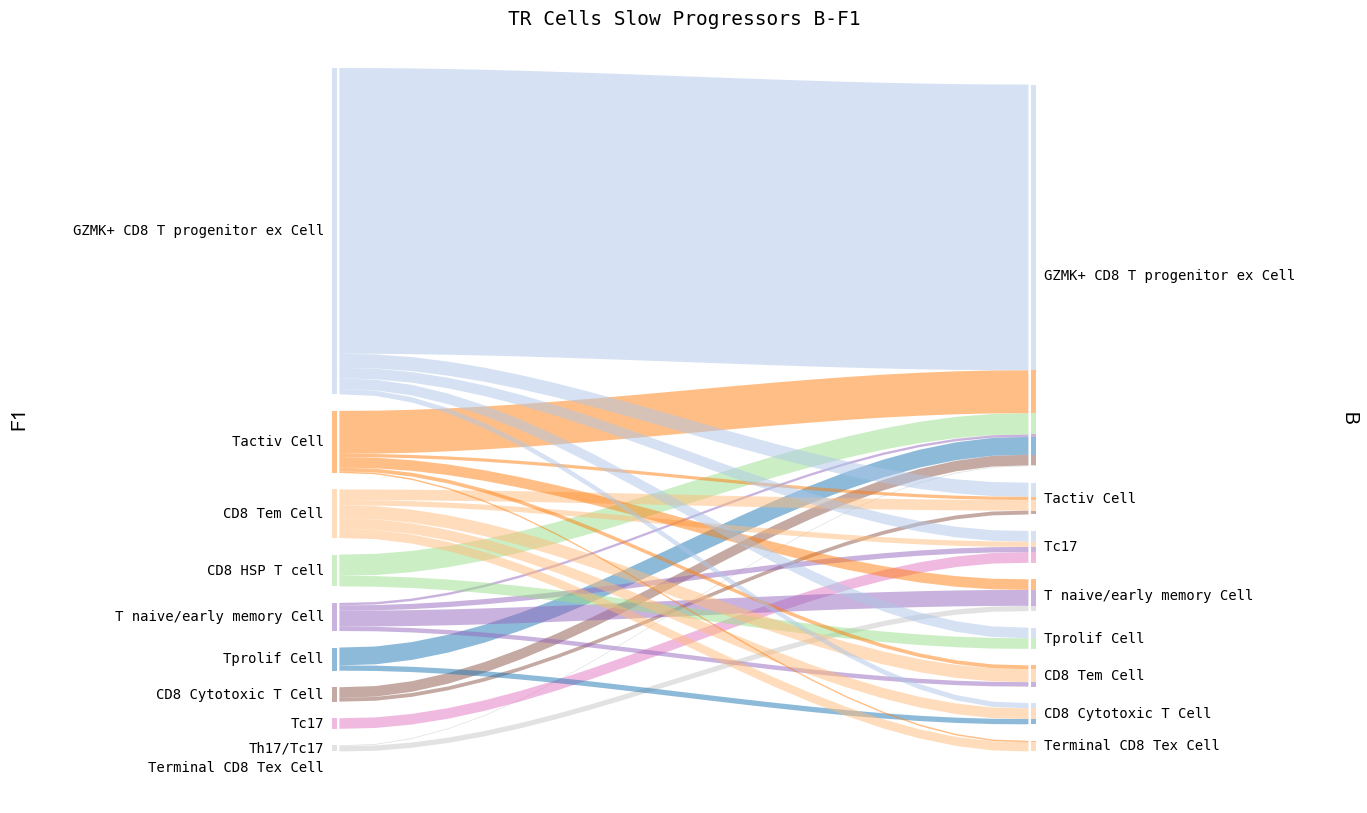

In [87]:
ax=alluvial.plot(flow_dict_sub,
                 colors=colors,
                 color_side=0,labels=('F1','B'),h_gap_frac=0.015)
fig = ax.get_figure()
fig.set_size_inches(10,10)
ax.set_title('TR Cells Slow Progressors B-F1', fontsize=14, fontname='Monospace')
plt.show()

# Alluvial Plots (fast)

In [88]:
dist_b_slow = adata[(
    adata.obs['timepoint'] == 'B'
    ) & (adata.obs['progression'] == 'Fast')].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_b_slow = dist_b_slow.div(dist_b_slow.sum(axis=1),axis=0)

dist_f1_slow =  adata[(
    adata.obs['timepoint'] == 'F1'
    ) & (adata.obs['progression'] == 'Fast')].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f1_slow = dist_f1_slow.div(dist_f1_slow.sum(axis=1),axis=0)

dist_f2_slow = adata[(
    adata.obs['timepoint'] == 'F2'
    ) & (adata.obs['progression'] == 'Fast')].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f2_slow = dist_f2_slow.div(dist_f2_slow.sum(axis=1),axis=0)

In [89]:
import random
clonotype_end = {}
for i in dist_f2_slow.index:
    temp = dist_f2_slow.loc[i]
    if temp.max() == 0.5:
        clonotype_end[i] = random.choice(temp[temp == .5].index.tolist())
    else:
        clonotype_end[i] = temp.idxmax()

In [90]:
dist_f1_slow.index = dist_f1_slow.index.map(clonotype_end)

In [91]:
dist_f1_slow_grouped = dist_f1_slow.groupby(level=0).sum()

In [92]:
dist_f1_slow_grouped.index = [i + ' ' for i in dist_f1_slow_grouped.index]

In [93]:
import sys
sys.path.append(os.path.abspath("/home/jupyter/data/ge_korea/tcr_analysis/notebooks_2024"))
import alluvial

In [94]:
flow_dict = dist_f1_slow_grouped.to_dict()

In [95]:
flow_dict_sub = {i : v for i , v in flow_dict.items()}

In [96]:
flow_dict_sub_new = {}
for i in flow_dict_sub.keys():
    temp = flow_dict_sub[i]
    flow_dict_sub_new[i] = {i : v for i, v in temp.items() if v > 0}

In [97]:
flow_dict_sub_new.keys()

dict_keys(['CD8 Cytotoxic T Cell', 'CD8 HSP T cell', 'CD8 Tem Cell', 'GZMK+ CD8 T progenitor ex Cell', 'T naive/early memory Cell', 'Tactiv Cell', 'Tc17', 'Terminal CD8 Tex Cell', 'Th17/Tc17', 'Tprolif Cell'])

In [98]:
colors

['#f7b6d2',
 '#c7c7c7',
 '#e377c2',
 '#8c564b',
 '#1f77b4',
 '#9467bd',
 '#98df8a',
 '#ffbb78',
 '#ff7f0e',
 '#aec7e8']

In [99]:
colors = ['Th17/Tc17','CD8 HSP T cell','T naive/early memory Cell',
          'Terminal CD8 Tex Cell','Tc17','CD8 Cytotoxic T Cell',
          'CD8 Tem Cell',
          'Tprolif Cell',
          'Tactiv Cell',
          'GZMK+ CD8 T progenitor ex Cell']
colors = [color_dict[i] for i in colors]

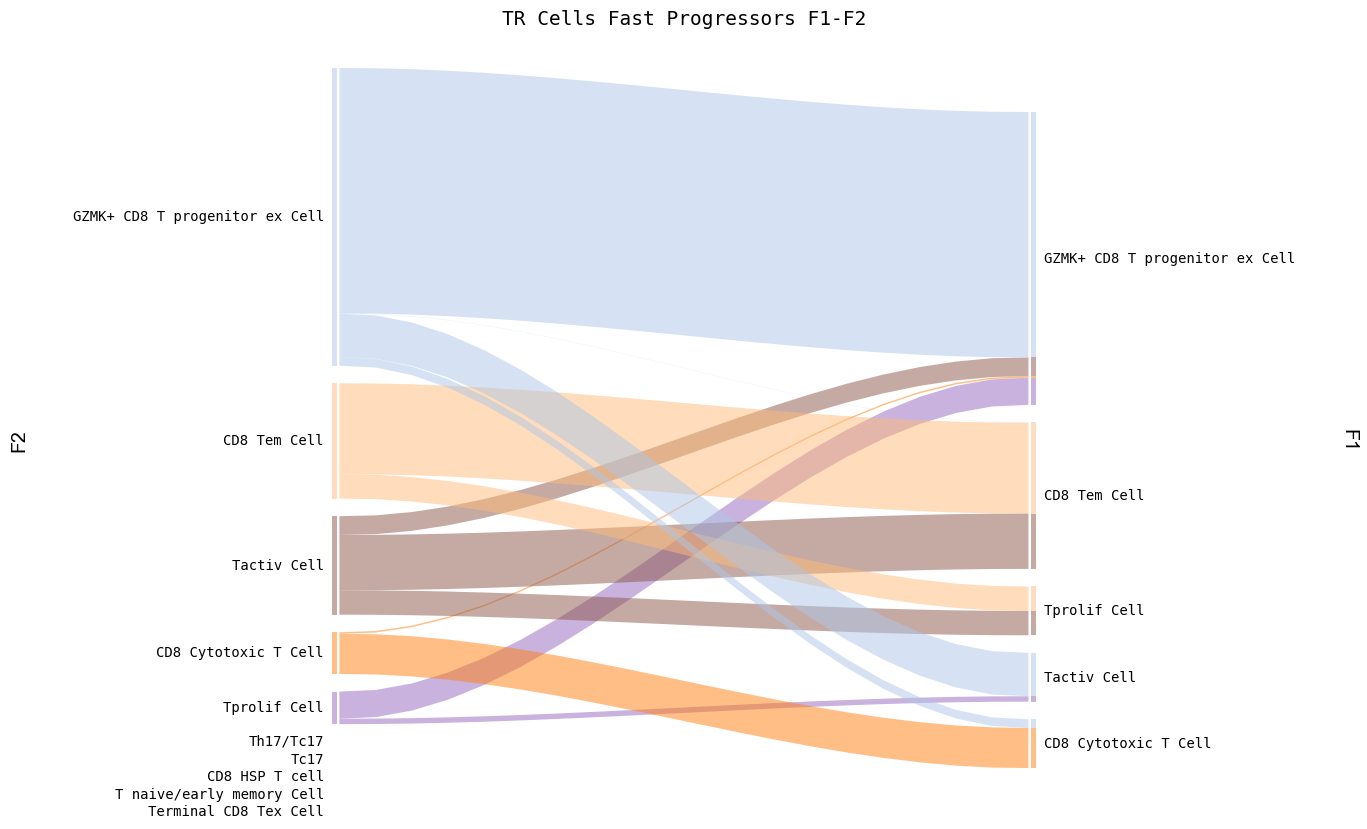

In [100]:
ax=alluvial.plot(flow_dict_sub_new,
                 colors=colors,
                 color_side=0,labels=('F2','F1'),h_gap_frac=0.015)
fig = ax.get_figure()
fig.set_size_inches(10,10)
ax.set_title('TR Cells Fast Progressors F1-F2', fontsize=14, fontname='Monospace')
plt.show()

In [101]:
dist_b_slow = adata[(
    adata.obs['timepoint'] == 'B'
    ) & (adata.obs['progression'] == 'Fast')].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_b_slow = dist_b_slow.div(dist_b_slow.sum(axis=1),axis=0)

dist_f1_slow =  adata[(
    adata.obs['timepoint'] == 'F1'
    ) & (adata.obs['progression'] == 'Fast')].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f1_slow = dist_f1_slow.div(dist_f1_slow.sum(axis=1),axis=0)

dist_f2_slow = adata[(
    adata.obs['timepoint'] == 'F2'
    ) & (adata.obs['progression'] == 'Fast')].obs[['clonotype_patient','annot_final']].value_counts().reset_index().pivot(
    columns='annot_final',index='clonotype_patient',values=0
    ).fillna(0)
dist_f2_slow = dist_f2_slow.div(dist_f2_slow.sum(axis=1),axis=0)

In [102]:
import random
clonotype_end = {}
for i in dist_f1_slow.index:
    temp = dist_f1_slow.loc[i]
    if temp.max() == 0.5:
        clonotype_end[i] = random.choice(temp[temp == .5].index.tolist())
    else:
        clonotype_end[i] = temp.idxmax()

In [103]:
dist_b_slow.index = dist_b_slow.index.map(clonotype_end)

In [104]:
dist_b_slow_grouped = dist_b_slow.groupby(level=0).sum()

In [105]:
dist_b_slow_grouped.index = [i + ' ' for i in dist_b_slow_grouped.index]

In [106]:
flow_dict = dist_b_slow_grouped.to_dict()

In [107]:
flow_dict_sub = {i : v for i , v in flow_dict.items()}

In [108]:
flow_dict_sub_new = {}
for i in flow_dict_sub.keys():
    temp = flow_dict_sub[i]
    flow_dict_sub_new[i] = {i : v for i, v in temp.items() if v > 0}

In [109]:
colors=['CD8 HSP T cell','T naive/early memory Cell','Tc17',
        'Terminal CD8 Tex Cell','Tactiv Cell',
        'CD8 Cytotoxic T Cell',
        'CD8 Tem Cell',
        'GZMK+ CD8 T progenitor ex Cell']
colors = [color_dict[i] for i in colors]

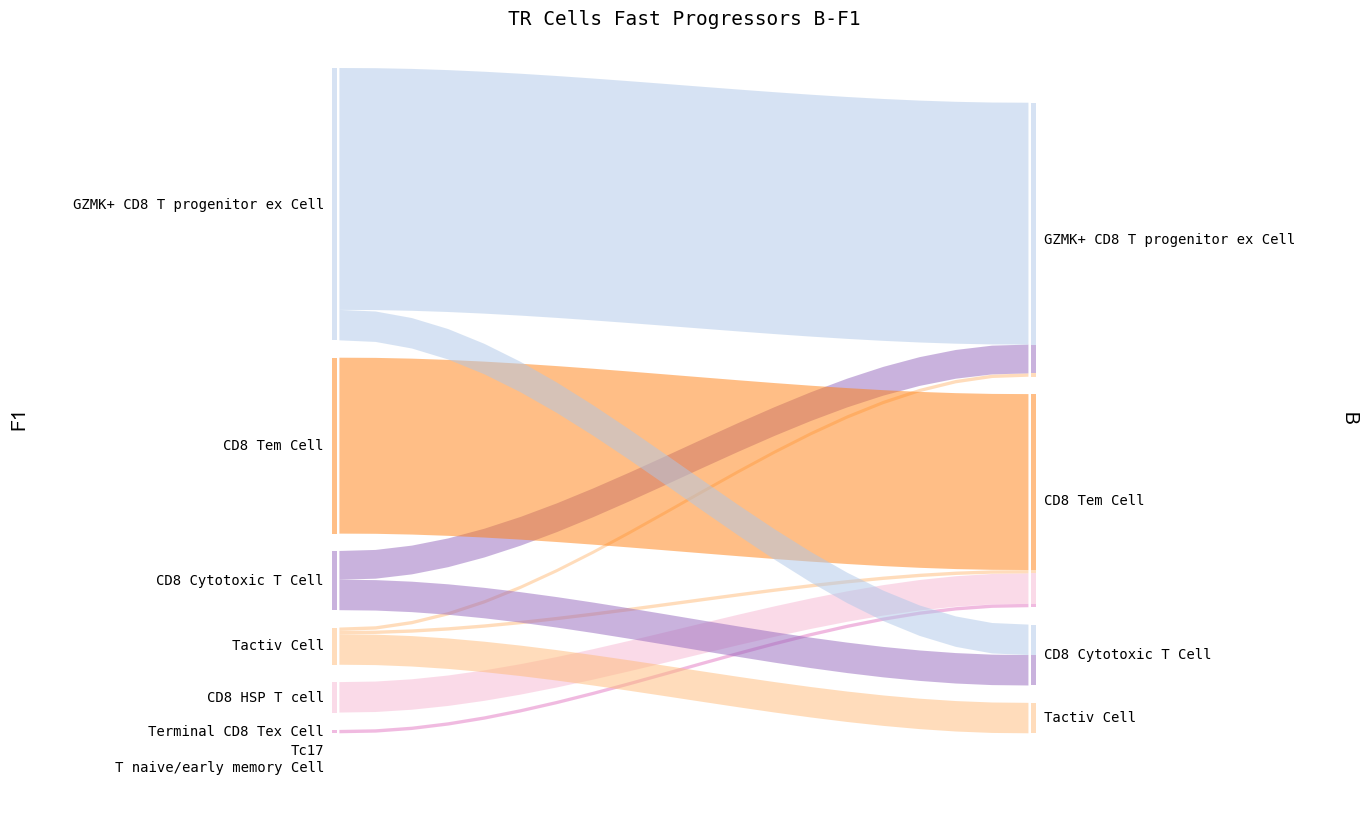

In [110]:
ax=alluvial.plot(flow_dict_sub,
                 colors=colors,
                 color_side=0,labels=('F1','B'),h_gap_frac=0.015)
fig = ax.get_figure()
fig.set_size_inches(10,10)
ax.set_title('TR Cells Fast Progressors B-F1', fontsize=14, fontname='Monospace')
plt.show()